# 🧠 Deep Learning Practical Assignment (Adult Income Dataset)

## 📌 Dataset
We will use the **Adult Income dataset** (also known as the Census Income dataset).  
The task is to predict whether a person earns **more than $50K/year** based on demographic and employment attributes.

---


In [1]:
# Option 1: Using OpenML via scikit-learn
from sklearn.datasets import fetch_openml
import pandas as pd

# Load dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame

print(df.head())
print(df.shape)  # (48842, 15)

# Separate features and target
X = df.drop(columns="class")
y = df["class"].apply(lambda v: 1 if v == ">50K" else 0)

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

## Part 0: Data Preparation
1. Load the dataset into a DataFrame.
2. Split the data into **training, validation, and test sets**.  
   - Suggested: 70% training, 15% validation, 15% test.
3. Apply any necessary preprocessing:
   - Handle categorical features (encoding).
   - Scale numerical features if needed.
4. After training your models, always report results on:
   - **Training accuracy**
   - **Validation accuracy**
   - **Test accuracy**
5. At the end of the assignment, **compare all methods** across train, validation, and test sets.


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)


categorical = X.select_dtypes(include="category").columns.tolist() + X.select_dtypes(include="object").columns.tolist()
numerical = X.select_dtypes(include=np.number).columns.tolist()
preprocessor = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), categorical),("num", StandardScaler(), numerical)])


X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)


X_train_tensor = torch.tensor(X_train_prep.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_prep.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_prep.toarray(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)



## Part 1: Optimizers
1. Train the same neural network using:
   - Stochastic Gradient Descent (SGD)
   - SGD with Momentum
   - Adam
2. Compare the training and validation accuracy for each optimizer.
3. Which optimizer converges the fastest? Which gives the best generalization?
4. Explain *why* Adam often performs better than plain SGD.

---


# 3.Which optimizer converges the fastest? Which gives the best generalization?

**Adam usually converges the fastest.
This is because Adam combines the benefits of Momentum and Adaptive Learning Rates. It adjusts the learning rate individually for each parameter and also uses past gradients to stabilize updates. This allows the model to reach a good solution faster than plain SGD.,
In many practical cases, Adam or SGD with Momentum provides better performance than plain SGD.
However, sometimes SGD with Momentum can generalize slightly better because Adam may adapt too aggressively to the training data.**

# 4.Explain why Adam often performs better than plain SGD.

**Adam performs better because it combines two important ideas:
Momentum:
Momentum helps accelerate learning by accumulating gradients from previous steps, allowing the optimizer to move consistently in the correct direction.
Adaptive Learning Rates:
Adam automatically adjusts the learning rate for each parameter based on past gradients. This allows the optimizer to handle sparse gradients and different feature scales more effectively.
Because of these properties, Adam typically converges faster and requires less manual tuning than SGD.**

In [3]:
class Net(nn.Module):

    def __init__(self, input_dim):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(input_dim,64)
        self.fc2 = nn.Linear(64,32)
        self.fc3 = nn.Linear(32,1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))

        return x


def evaluate(model,X,y):

    model.eval()

    with torch.no_grad():

        preds = model(X).view(-1)

        acc = ((preds>0.5)==y).float().mean().item()

    return acc


def train_model(optimizer_name,batch_size=128,epochs=10,weight_decay=0):

    model = Net(X_train_tensor.shape[1])

    criterion = nn.BCELoss()

    if optimizer_name=="SGD":
        optimizer = optim.SGD(model.parameters(),lr=0.01)

    elif optimizer_name=="Momentum":
        optimizer = optim.SGD(model.parameters(),lr=0.01,momentum=0.9)

    elif optimizer_name=="Adam":
        optimizer = optim.Adam(model.parameters(),lr=0.001,weight_decay=weight_decay)

    train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)

    for epoch in range(epochs):

        model.train()

        for xb,yb in train_loader:

            optimizer.zero_grad()

            preds = model(xb).view(-1)

            loss = criterion(preds,yb)

            loss.backward()

            optimizer.step()

    train_acc = evaluate(model,X_train_tensor,y_train_tensor)
    val_acc = evaluate(model,X_val_tensor,y_val_tensor)
    test_acc = evaluate(model,X_test_tensor,y_test_tensor)

    return model,train_acc,val_acc,test_acc

results = []

for opt in ["SGD","Momentum","Adam"]:

    model,train_acc,val_acc,test_acc = train_model(opt)

    results.append(["Optimizer-"+opt,train_acc,val_acc,test_acc])


## Part 2: Batch Size
1. Train the same model with different batch sizes (e.g., 1, 32, 128, 1024).
2. Compare:
   - Training speed
   - Validation accuracy
   - Test accuracy
   - Generalization ability
3. Which batch size leads to the **noisiest gradient updates**?
4. Which batch size generalizes better and why?

# 3.Which batch size leads to the noisiest gradient updates?

**Batch size = 1 produces the noisiest gradients.
This is because the gradient is computed using only a single training example. Therefore, the updates vary significantly from step to step, which introduces high variance in the optimization process.**

# 4.Which batch size generalizes better and why?

Smaller batch sizes (such as 32 or 128) often generalize better.

**Smaller batches introduce noise in the gradient updates, which can help the optimizer escape sharp minima and find flatter solutions that generalize better to unseen data.Very large batch sizes may converge faster but can lead to poorer generalization.**

In [5]:
for batch in [1,32,128,1024]:

    model,train_acc,val_acc,test_acc = train_model("Adam",batch_size=batch)

    results.append([f"Batch-{batch}",train_acc,val_acc,test_acc])


## Part 3: Overfitting and Regularization
1. Train a large neural network (many parameters) on the dataset.
2. Observe training vs. validation accuracy.  
   - Do you see signs of overfitting?
3. Apply regularization techniques:
   - **L2 regularization**
   - **Dropout**
4. Compare the validation results before and after regularization.
5. Which regularization method was more effective in reducing overfitting? Why?

---


# Do you see signs of overfitting?

**Yes. Overfitting occurs when the training accuracy becomes significantly higher than the validation accuracy. This indicates that the model memorizes the training data instead of learning general patterns.**

#5. Which regularization method was more effective in reducing overfitting? Why?

**In many deep learning models, Dropout is often more effective than L2 regularization because it directly prevents co-adaptation between neurons and acts as a form of model averaging.**

In [6]:
model,train_acc,val_acc,test_acc = train_model("Adam",weight_decay=0.001)

results.append(["L2 Regularization",train_acc,val_acc,test_acc])

class DropoutNet(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.fc1 = nn.Linear(input_dim,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.sigmoid(self.fc3(x))

        return x

def train_dropout():

    model = DropoutNet(X_train_tensor.shape[1])

    optimizer = optim.Adam(model.parameters(),lr=0.001)
    criterion = nn.BCELoss()

    for epoch in range(10):

        preds = model(X_train_tensor).squeeze()

        loss = criterion(preds,y_train_tensor)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_acc = evaluate(model,X_train_tensor,y_train_tensor)
    val_acc = evaluate(model,X_val_tensor,y_val_tensor)
    test_acc = evaluate(model,X_test_tensor,y_test_tensor)

    return train_acc,val_acc,test_acc

train_acc,val_acc,test_acc = train_dropout()

results.append(["Dropout",train_acc,val_acc,test_acc])


## Part 4: Early Stopping
1. Train the model for many epochs without early stopping.  
   - Plot training, validation, and test curves.
2. Train again with **early stopping** (monitor validation loss).
3. Compare the number of epochs trained and the final validation/test accuracy.
4. Explain how early stopping helps prevent overfitting.

---

# 4.Explain how early stopping helps prevent overfitting.

**Early stopping monitors the validation loss during training. When the validation performance stops improving, training is stopped automatically.
This prevents the model from continuing to learn patterns that only exist in the training data, which helps improve generalization.**

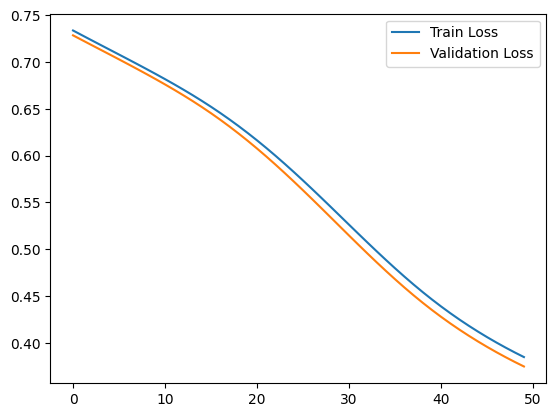


Final Comparison:
               Method  Train Accuracy  Validation Accuracy  Test Accuracy
0       Optimizer-SGD        0.843107             0.849167       0.843456
1  Optimizer-Momentum        0.855860             0.860770       0.856831
2      Optimizer-Adam        0.863202             0.864319       0.856012
3             Batch-1        0.868203             0.864592       0.862017
4            Batch-32        0.868145             0.862271       0.851099
5           Batch-128        0.862441             0.863227       0.859015
6          Batch-1024        0.858434             0.860770       0.857377
7   L2 Regularization        0.859428             0.860633       0.855466
8             Dropout        0.760713             0.760715       0.760748
9      Early Stopping        0.822574             0.826645       0.819571


In [8]:
import matplotlib.pyplot as plt

def train_early_stopping(patience=5):

    model = Net(X_train_tensor.shape[1])

    optimizer = optim.Adam(model.parameters(),lr=0.001)
    criterion = nn.BCELoss()

    best_loss = float("inf")
    counter = 0

    train_losses=[]
    val_losses=[]

    for epoch in range(50):

        model.train()

        preds = model(X_train_tensor).squeeze()

        loss = criterion(preds,y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()

        with torch.no_grad():

            val_pred = model(X_val_tensor).squeeze()

            val_loss = criterion(val_pred,y_val_tensor)

        val_losses.append(val_loss.item())

        if val_loss < best_loss:

            best_loss = val_loss
            counter = 0

        else:

            counter+=1

            if counter>=patience:

                print("Early stopping at epoch",epoch)
                break

    plt.plot(train_losses,label="Train Loss")
    plt.plot(val_losses,label="Validation Loss")
    plt.legend()
    plt.show()

    train_acc = evaluate(model,X_train_tensor,y_train_tensor)
    val_acc = evaluate(model,X_val_tensor,y_val_tensor)
    test_acc = evaluate(model,X_test_tensor,y_test_tensor)

    return train_acc,val_acc,test_acc

train_acc,val_acc,test_acc = train_early_stopping()

results.append(["Early Stopping",train_acc,val_acc,test_acc])


results_df = pd.DataFrame(
    results,
    columns=["Method","Train Accuracy","Validation Accuracy","Test Accuracy"]
)

print("\nFinal Comparison:")
print(results_df)

## Part 5: Reflection
1. Summarize what you learned about:
   - The role of optimizers
   - The effect of batch size
   - Regularization methods
   - Early stopping
   - Train/validation/test splits
2. If you had to train a deep learning model on a new tabular dataset, what choices would you make for:
   - Optimizer
   - Batch size
   - Regularization
   - Early stopping
   - Data splitting strategy  
   and why?

# Role of Optimizers

**Optimizers determine how the neural network updates its parameters during training. Advanced optimizers such as Adam improve convergence speed and training stability compared to basic methods like SGD.**

# Effect of Batch Size

**Batch size controls how many samples are used to compute each gradient update. Small batch sizes introduce noise that may help generalization, while large batches provide more stable gradients but may generalize worse.**

# Regularization Methods

**Regularization techniques such as L2 regularization and Dropout help prevent overfitting by limiting model complexity and forcing the network to learn more robust patterns.**

# Early Stopping

**Early stopping stops training when validation performance stops improving. This prevents the model from memorizing training data and improves generalization.**

# Train / Validation / Test Splits

**Separating the dataset into train, validation, and test sets allows fair model evaluation. The validation set helps tune hyperparameters, while the test set provides an unbiased evaluation of final model performance.**

# If training a new tabular dataset
# Optimizer

**I would choose Adam because it converges faster and requires less manual tuning.**

# Batch Size

**I would start with 32 or 128, as these batch sizes usually balance training stability and generalization.**

# Regularization

**I would apply Dropout and L2 regularization to reduce overfitting.**

# Early Stopping

**I would monitor validation loss with patience around 5–10 epochs.**

# Data Splitting Strategy

**I would use 70% training, 15% validation, and 15% test to ensure reliable model evaluation.**